# Shot Boundary Detection -- Experimentation Notebook

This notebook loads the sample videos and their ground-truth ad-insertion metadata,
runs several shot-boundary detection methods, and visualises detected boundaries
against the ground truth.

**Ground truth** marks where ads were inserted (content/ad transitions).  
Our detectors may find *more* boundaries (every scene/camera change), which is fine.

In [1]:
# Auto-reload so edits to .py files take effect without restarting the kernel
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

from video_utils import (
    load_video_info,
    list_available_videos,
    get_video_fps,
    get_video_frame_count,
    get_ground_truth_boundaries,
    get_ground_truth_ad_intervals,
    plot_signal_with_boundaries,
    plot_boundary_comparison,
    show_frames_at_indices,
    seconds_to_timestamp,
)
from shot_detection import (
    ALL_DETECTORS,
    FrameDifferenceDetector,
    HistogramDifferenceDetector,
    EntropyChangeDetector,
    EdgeChangeRatioDetector,
    OpticalFlowMagnitudeDetector,
    DetectionResult,
)

plt.rcParams['figure.dpi'] = 100

## 1. List available videos & pick one to work with

In [2]:
available = list_available_videos()
print("Available videos:", available)

# --- Pick the video to analyse ---
VIDEO_NAME = "test_001"  # <-- change this to try other videos

Available videos: ['test_001', 'test_002', 'test_003', 'test_004', 'test_005']


## 2. Load video metadata & ground truth

In [3]:
info = load_video_info(VIDEO_NAME)
fps = get_video_fps(info.video_path)
total_frames = get_video_frame_count(info.video_path)

print(f"Video       : {info.video_filename}")
print(f"Duration    : {info.duration_sec:.1f}s  ({seconds_to_timestamp(info.duration_sec)})")
print(f"Resolution  : {info.resolution}")
print(f"FPS         : {fps}")
print(f"Total frames: {total_frames}")
print(f"Ads inserted: {len(info.ads)}")
print()

gt_boundaries = get_ground_truth_boundaries(info, fps)
gt_intervals  = get_ground_truth_ad_intervals(info, fps)

print("Ground-truth ad boundary frames:")
for i, ad in enumerate(info.ads):
    sf = int(round(ad.start_sec * fps))
    ef = int(round(ad.end_sec * fps))
    print(f"  Ad {ad.ad_index}: frames {sf} - {ef}  "
          f"({seconds_to_timestamp(ad.start_sec)} - {seconds_to_timestamp(ad.end_sec)})")

Video       : test_001.mp4
Duration    : 1458.6s  (00:24:18.603)
Resolution  : (640, 360)
FPS         : 29.87537252241455
Total frames: 43571
Ads inserted: 3

Ground-truth ad boundary frames:
  Ad 1: frames 3172 - 6704  (00:01:46.159 - 00:03:44.395)
  Ad 2: frames 18767 - 19726  (00:10:28.163 - 00:11:00.276)
  Ad 3: frames 32525 - 33373  (00:18:08.698 - 00:18:37.073)


### 2a. Visualise the ground-truth boundary frames

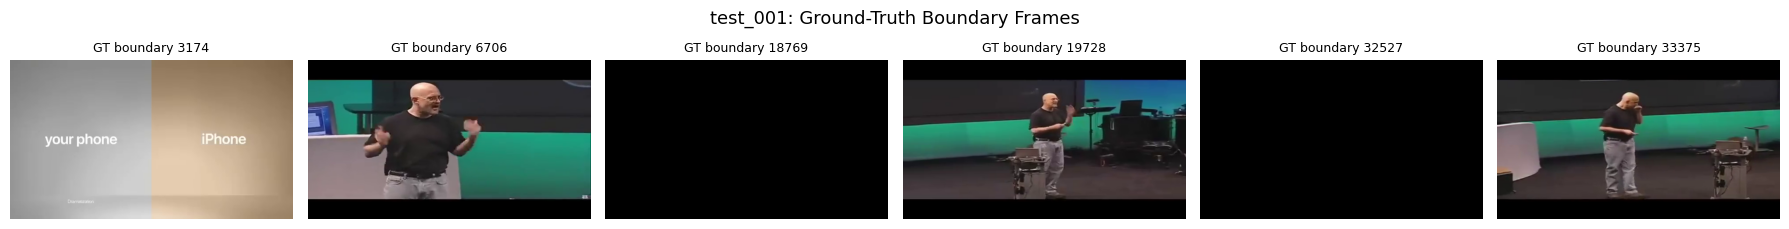

In [4]:
# Show a thumbnail at each ground-truth boundary
fig = show_frames_at_indices(
    info.video_path,
    gt_boundaries,
    label="GT boundary",
    max_show=12,
)
fig.suptitle(f"{VIDEO_NAME}: Ground-Truth Boundary Frames", fontsize=13, y=1.02)
plt.show()

## 3. Configure detection parameters

Tune these knobs to experiment.

In [5]:
# Sampling stride -- process every N-th frame (higher = faster but coarser)
SAMPLE_EVERY = 30

# Adaptive threshold multiplier (mean + k * std)
ADAPTIVE_K = 3.0

# Minimum gap between consecutive detections (in sampled frames)
MIN_GAP = 15

# Which detectors to run (from ALL_DETECTORS, or build a custom list)
detectors_to_run = ALL_DETECTORS

# Uncomment to add the slow optical-flow detector:
# detectors_to_run = ALL_DETECTORS + [OpticalFlowMagnitudeDetector()]

## 4. Run all detectors

In [6]:
results: dict[str, DetectionResult] = {}

for det in detectors_to_run:
    start = time.time()
    print(f"Running: {det.name} ...", end=" ", flush=True)
    res = det.detect(
        info.video_path,
        sample_every=SAMPLE_EVERY,
        adaptive=True,
        adaptive_k=ADAPTIVE_K,
        min_gap_frames=MIN_GAP,
    )
    results[det.name] = res
    print(f"detected {len(res.detected_frames)} boundaries  (threshold={res.threshold:.4f}), in {time.time() - start:.1f}s")

print("\nDone.")

Running: Hybrid TransNet + CLIP ... 

d:\USCrelated\Sem-4\Multimedia\Assignments\Project\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


detected 74 boundaries  (threshold=0.3000), in 49.8s

Done.


## 5. Visualise each method: score signal + boundaries

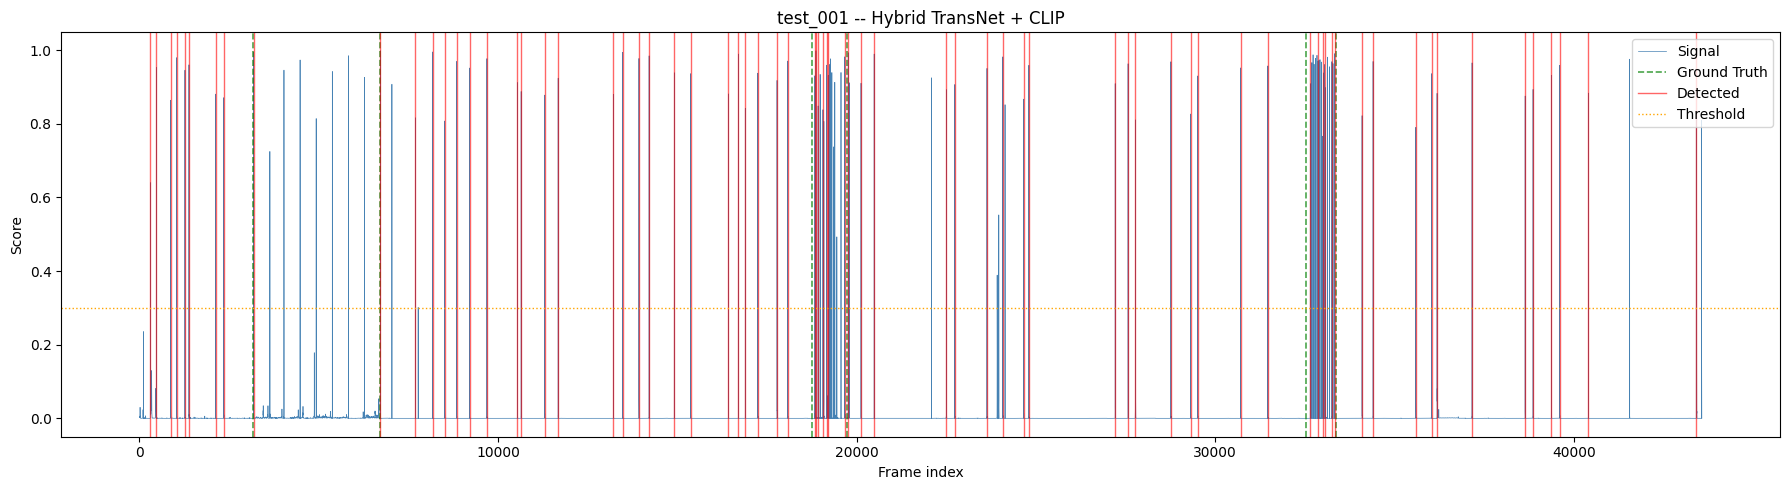

In [7]:
for name, res in results.items():
    # Use each detector's own sample_every (TransNet's is 1, others match
    # SAMPLE_EVERY). This keeps the signal, detected markers, and GT
    # markers aligned on the same x-axis regardless of the stride.
    stride = max(res.sample_every, 1)
    gt_sampled = [f // stride for f in gt_boundaries]

    fig = plot_signal_with_boundaries(
        res.scores,
        detected_frames=[f // stride for f in res.detected_frames],
        ground_truth_frames=gt_sampled,
        fps=fps,
        title=f"{VIDEO_NAME} -- {name}",
        ylabel="Score",
        threshold=res.threshold,
    )
    plt.show()

## 6. Timeline comparison: detected vs ground-truth

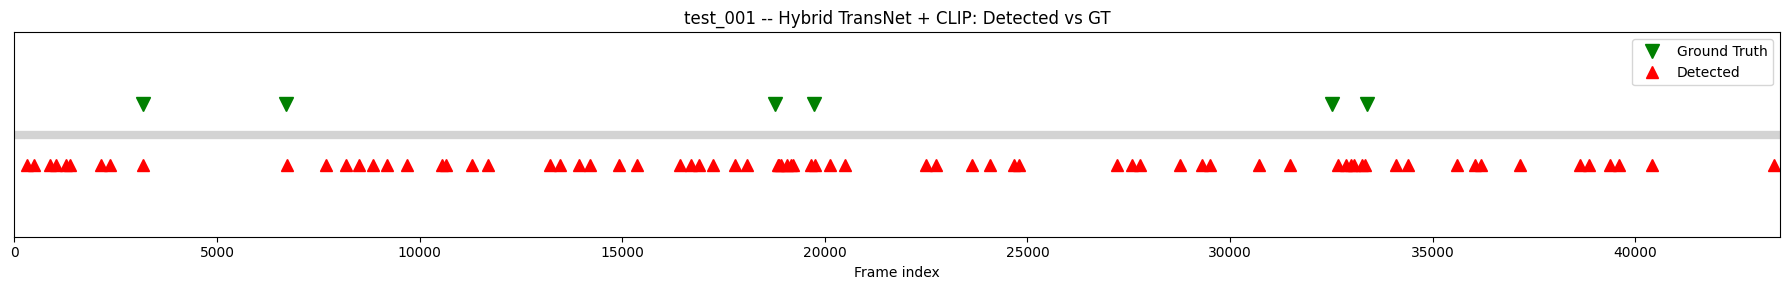

In [8]:
for name, res in results.items():
    fig = plot_boundary_comparison(
        res.detected_frames,
        gt_boundaries,
        total_frames,
        fps=fps,
        title=f"{VIDEO_NAME} -- {name}: Detected vs GT",
    )
    plt.show()

## 7. Show detected boundary frames (thumbnails)


=== Hybrid TransNet + CLIP: 74 detected boundaries ===


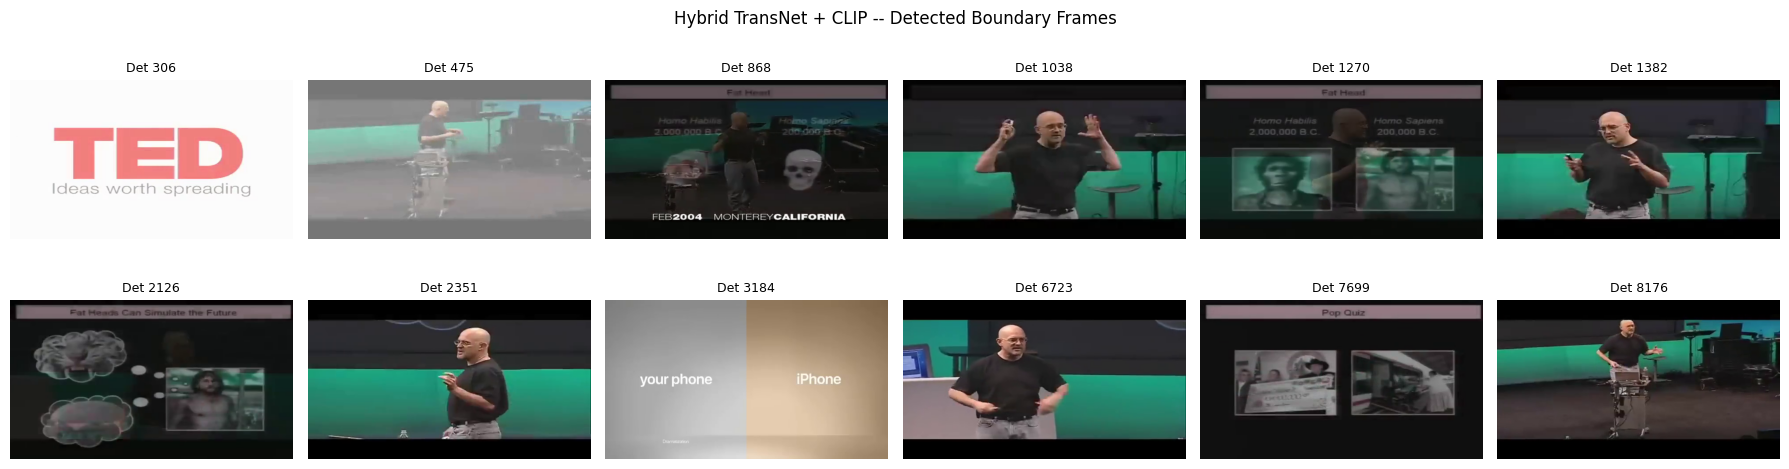

In [9]:
for name, res in results.items():
    print(f"\n=== {name}: {len(res.detected_frames)} detected boundaries ===")
    fig = show_frames_at_indices(
        info.video_path,
        res.detected_frames,
        label="Det",
        max_show=12,
    )
    fig.suptitle(f"{name} -- Detected Boundary Frames", fontsize=12, y=1.02)
    plt.show()

## 8. Quantitative evaluation (precision / recall against GT)

A detected boundary is a **true positive** if it falls within `TOLERANCE` frames of a
ground-truth boundary.

In [10]:
TOLERANCE_FRAMES = int(fps * 2)  # 2-second tolerance window

def evaluate(detected: list[int], ground_truth: list[int], tol: int) -> dict:
    """Compute precision, recall, F1 given a frame-index tolerance."""
    gt_matched = set()
    tp = 0
    for d in detected:
        for g in ground_truth:
            if abs(d - g) <= tol and g not in gt_matched:
                tp += 1
                gt_matched.add(g)
                break
    precision = tp / len(detected) if detected else 0.0
    recall    = tp / len(ground_truth) if ground_truth else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"TP": tp, "detected": len(detected), "GT": len(ground_truth),
            "precision": precision, "recall": recall, "F1": f1}

print(f"Tolerance: {TOLERANCE_FRAMES} frames ({TOLERANCE_FRAMES/fps:.1f}s)\n")
print(f"{'Method':<35s}  {'TP':>3s} {'Det':>4s} {'GT':>3s}  {'Prec':>6s} {'Rec':>6s} {'F1':>6s}")
print("-" * 75)
for name, res in results.items():
    m = evaluate(res.detected_frames, gt_boundaries, TOLERANCE_FRAMES)
    print(f"{name:<35s}  {m['TP']:3d} {m['detected']:4d} {m['GT']:3d}  "
          f"{m['precision']:6.3f} {m['recall']:6.3f} {m['F1']:6.3f}")

Tolerance: 59 frames (2.0s)

Method                                TP  Det  GT    Prec    Rec     F1
---------------------------------------------------------------------------
Hybrid TransNet + CLIP                 4   74   6   0.054  0.667  0.100


## 9. Side-by-side: GT frames vs nearest detected frame

For each ground-truth boundary, show the GT frame and the closest detected frame from the best method.

Best method by F1: Hybrid TransNet + CLIP



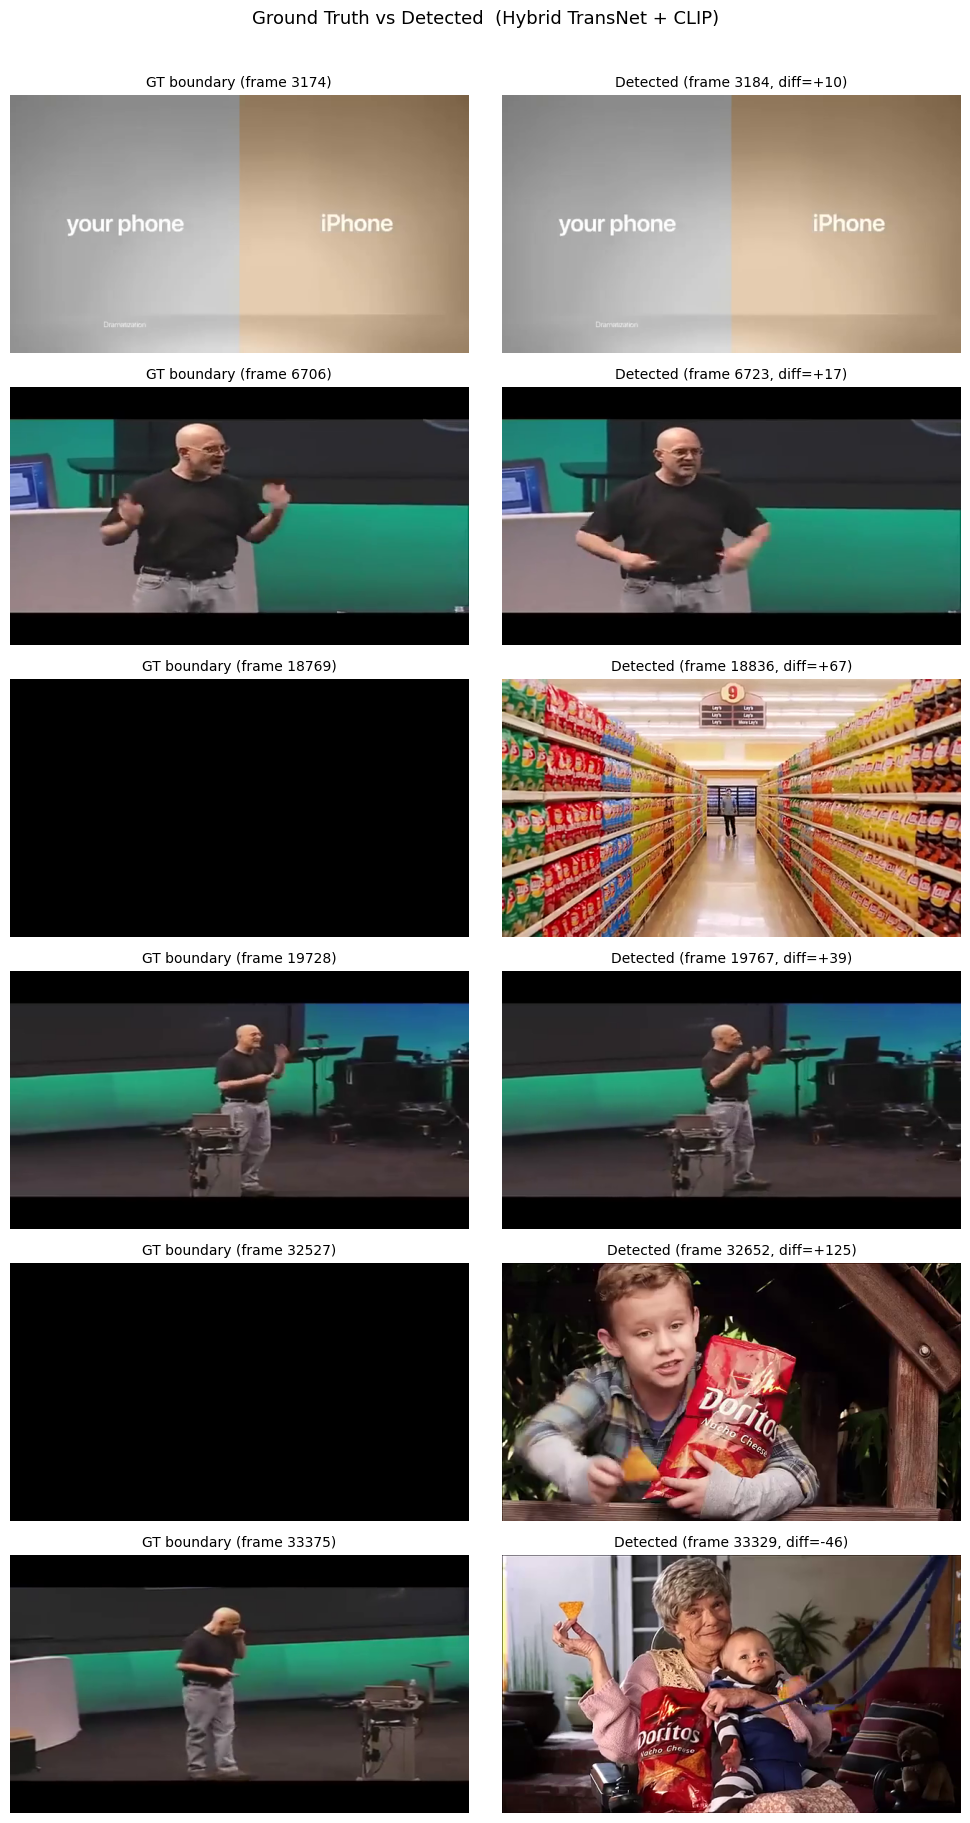

In [11]:
import cv2

# Pick the method with the best F1 for side-by-side display
best_name = max(results, key=lambda n: evaluate(results[n].detected_frames, gt_boundaries, TOLERANCE_FRAMES)["F1"])
best_res = results[best_name]
print(f"Best method by F1: {best_name}\n")

cap = cv2.VideoCapture(str(info.video_path))

def read_frame(cap, fidx):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
    ret, frame = cap.read()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((100, 100, 3), dtype=np.uint8)

n_gt = len(gt_boundaries)
fig, axes = plt.subplots(n_gt, 2, figsize=(10, 3 * n_gt))
if n_gt == 1:
    axes = axes[np.newaxis, :]

for i, gt_f in enumerate(gt_boundaries):
    # Find closest detected boundary
    if best_res.detected_frames:
        closest = min(best_res.detected_frames, key=lambda d: abs(d - gt_f))
    else:
        closest = gt_f

    axes[i, 0].imshow(read_frame(cap, gt_f))
    axes[i, 0].set_title(f"GT boundary (frame {gt_f})", fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(read_frame(cap, closest))
    diff = closest - gt_f
    axes[i, 1].set_title(f"Detected (frame {closest}, diff={diff:+d})", fontsize=10)
    axes[i, 1].axis("off")

cap.release()
fig.suptitle(f"Ground Truth vs Detected  ({best_name})", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 10. Run on all videos (batch summary)

In [12]:
from video_utils import load_video_info, get_video_fps, get_ground_truth_boundaries

summary_rows = []

for vname in list_available_videos():
    vinfo = load_video_info(vname)
    vfps = get_video_fps(vinfo.video_path)
    gt = get_ground_truth_boundaries(vinfo, vfps)

    for det in detectors_to_run:
        res = det.detect(
            vinfo.video_path,
            sample_every=SAMPLE_EVERY,
            adaptive=True,
            adaptive_k=ADAPTIVE_K,
            min_gap_frames=MIN_GAP,
        )
        m = evaluate(res.detected_frames, gt, TOLERANCE_FRAMES)
        summary_rows.append({"video": vname, "method": det.name, **m})
        print(f"{vname}  {det.name:<35s}  P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['F1']:.3f}")

print("\nBatch run complete.")

test_001  Hybrid TransNet + CLIP               P=0.054  R=0.667  F1=0.100
test_002  Hybrid TransNet + CLIP               P=0.000  R=0.000  F1=0.000
test_003  Hybrid TransNet + CLIP               P=0.058  R=1.000  F1=0.109
test_004  Hybrid TransNet + CLIP               P=0.013  R=0.167  F1=0.024
test_005  Hybrid TransNet + CLIP               P=0.075  R=1.000  F1=0.140

Batch run complete.


---

## Next steps / ideas to try

- Adjust `ADAPTIVE_K`, `MIN_GAP`, `SAMPLE_EVERY` per method
- Combine scores from multiple detectors (e.g. weighted sum, voting)
- Add audio-based detection (energy, spectral flux, silence detection)
- Use the optical flow detector (`OpticalFlowMagnitudeDetector`) -- slow but captures motion
- Try SSIM-based frame comparison
- Two-pass detection: coarse pass to find candidates, fine pass to refine
- Train a small classifier on multi-modal features to label segments as content vs ad